# MLP：用反向传播让神经网络学会分类

前面的分类模型各有限制：逻辑回归只能处理线性边界，SVM 需要核技巧来引入非线性，随机森林和 GBDT 用集成方法提升精度。MLP（Multilayer Perceptron，多层感知机）提供了一种更通用的思路——通过堆叠非线性变换层，让网络自动学习特征之间的复杂关系。

本文用 NumPy 实现 MLP（ReLU 隐藏层 + Softmax 输出 + 反向传播），在手写数字数据集上验证多类分类效果。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.mlp import MLP

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 数据集：Digits

Digits 手写数字数据集，1797 个 8×8 灰度图，10 个类别（0-9）。
用前两篇 PCA 的方法可以将 64 维降到 2 维可视化，这篇直接在原始 64 维上训练 MLP 分类器。

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print(f'样本数量: {X.shape[0]}, 特征维度: {X.shape[1]}, 类别数: {len(np.unique(y))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 标准化（梯度下降模型需要）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}')

样本数量: 1797, 特征维度: 64, 类别数: 10
训练集: 1437, 测试集: 360


## 2. 训练 MLP

网络结构：[64, 32, 10] 即 64 个输入 → 32 个 ReLU 隐藏神经元 → 10 个 Softmax 输出。
损失函数：交叉熵。优化：梯度下降。

In [3]:
mlp = MLP(layer_dims=[64, 32, 10], lr=0.1, epochs=1000)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'测试集准确率: {acc:.4f}')

测试集准确率: 0.9833


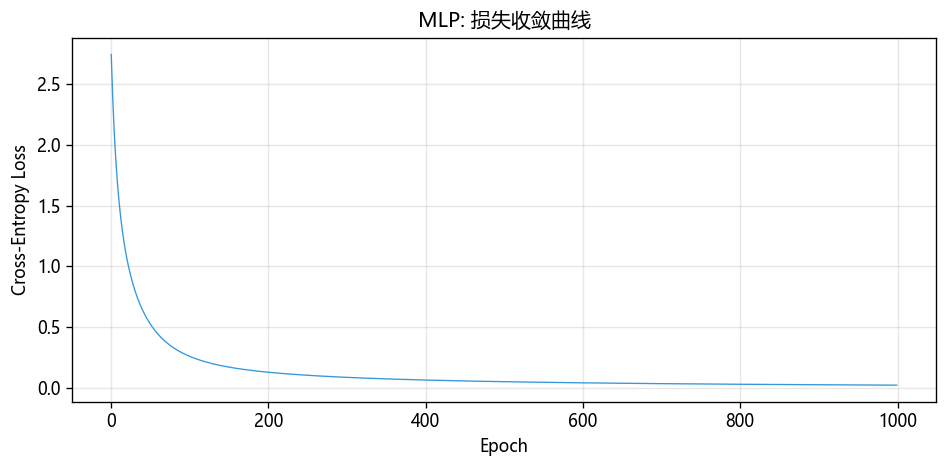

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.losses_, color='#3498db', lw=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('MLP: 损失收敛曲线')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

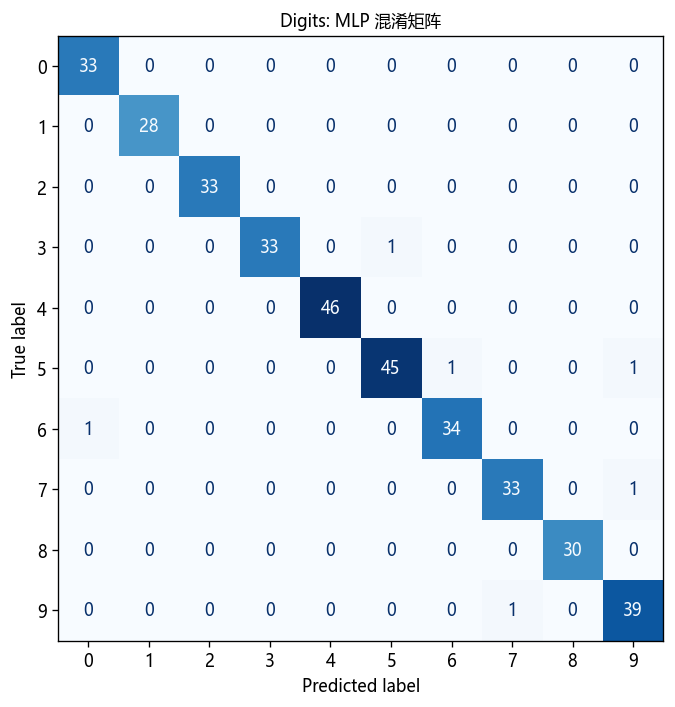

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Digits: MLP 混淆矩阵', fontsize=10)
plt.tight_layout()
plt.show()

## 3. 隐藏层大小 vs 精度

比较不同隐藏层配置的效果：无隐藏层（等价于 Softmax 回归）、32 个神经元、64 个神经元、两层隐藏层。观察模型容量对精度的影响。

Linear (no hidden)         acc=0.9639  loss=0.0814


[64, 16, 10]               acc=0.9611  loss=0.0320


[64, 32, 10]               acc=0.9833  loss=0.0218


[64, 64, 10]               acc=0.9778  loss=0.0191


[64, 64, 32, 10]           acc=0.9750  loss=0.0066


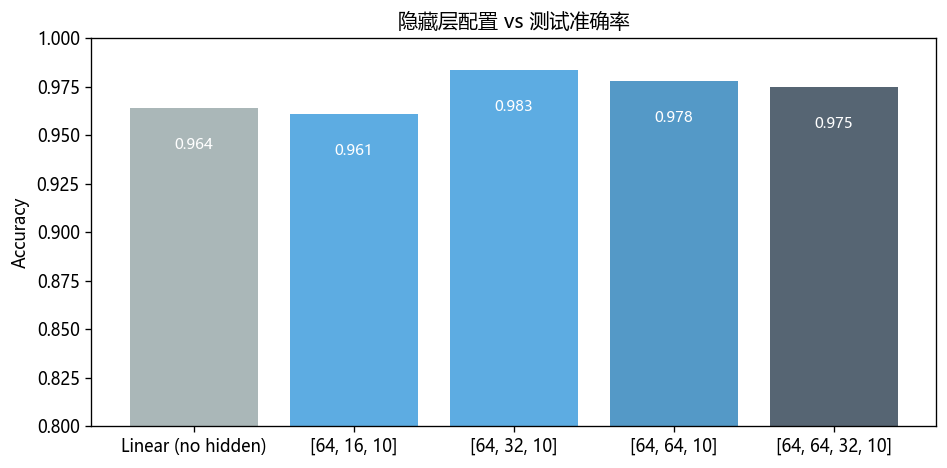

In [6]:
configs = [
    ('Linear (no hidden)', [64, 10]),
    ('[64, 16, 10]', [64, 16, 10]),
    ('[64, 32, 10]', [64, 32, 10]),
    ('[64, 64, 10]', [64, 64, 10]),
    ('[64, 64, 32, 10]', [64, 64, 32, 10]),
]

results = []
for name, dims in configs:
    model = MLP(layer_dims=dims, lr=0.1, epochs=1000)
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    acc = accuracy_score(y_test, yp)
    results.append((name, acc, model.losses_[-1]))
    print(f'{name:25s}  acc={acc:.4f}  loss={model.losses_[-1]:.4f}')

names, accs, _ = zip(*results)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, accs, color=['#95a5a6', '#3498db', '#3498db', '#2980b9', '#2c3e50'], alpha=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('隐藏层配置 vs 测试准确率')
ax.set_ylim(0.8, 1.0)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.015,
            f'{acc:.3f}', ha='center', va='top', fontsize=9, color='white')
plt.tight_layout()
plt.show()

## 4. 预测效果展示

随机展示测试集样本的预测结果，绿色为正确，红色为错误。

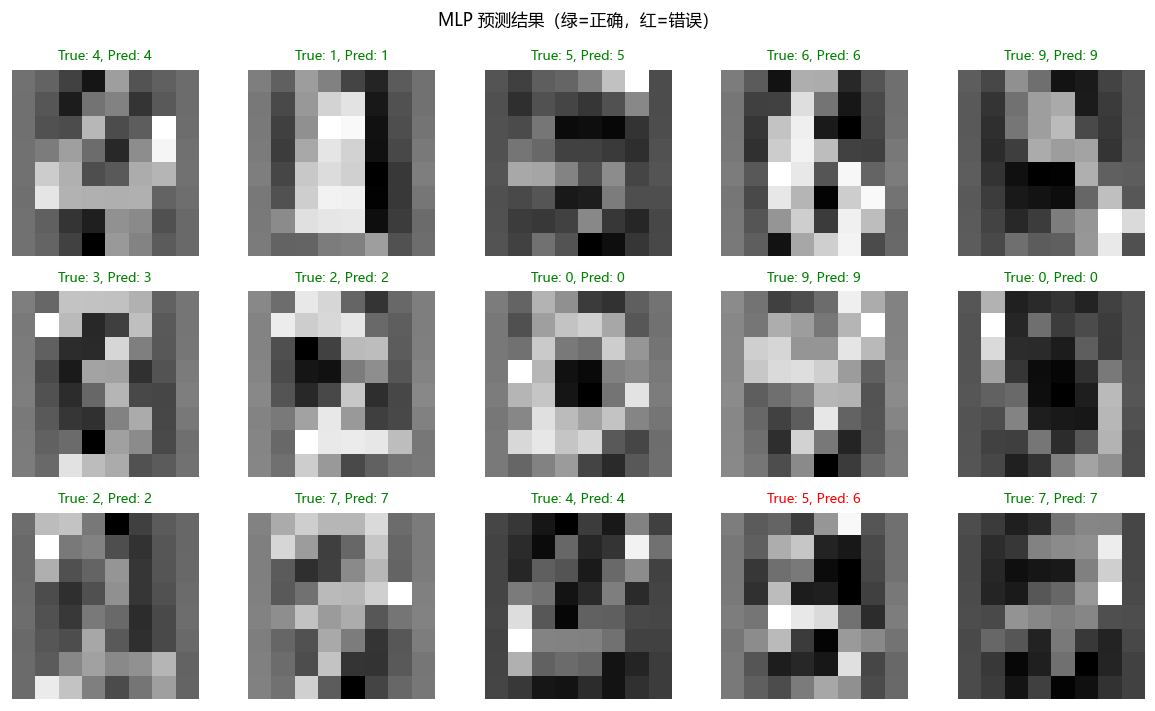

In [7]:
n_show = 15
indices = np.random.choice(len(X_test), n_show, replace=False)
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    idx = indices[i]
    img = X_test[idx].reshape(8, 8)
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    ax.imshow(img, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}, Pred: {pred_label}',
                 fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('MLP 预测结果（绿=正确，红=错误）', fontsize=10)
plt.tight_layout()
plt.show()

## 小结

- **MLP** 通过堆叠非线性隐藏层，可以学习数据中的复杂模式
- **反向传播** 是训练的核心算法——利用链式法则将损失梯度从输出层逐层传回输入层
- **隐藏层容量** 影响模型精度：无隐藏层 96.4% → 32 个神经元 98.3%
- MLP 的局限：全连接层参数量随输入维度平方增长（64→64 层需 4096 个参数），不适合图像等高维原始数据——这正是 CNN 要解决的问题
- 下一步：CNN（卷积神经网络），用局部连接和权值共享处理图像数据